In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/student_depression_ml.csv")

df_ml.head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,CGPA__missing,Financial Stress__missing,Gender_female,Gender_male,City_3.0,City_agra,City_ahmedabad,City_bangalore,City_bhavna,City_bhopal,City_chennai,City_city,City_delhi,City_faridabad,City_gaurav,City_ghaziabad,City_harsh,City_harsha,City_hyderabad,City_indore,City_jaipur,City_kalyan,City_kanpur,City_khaziabad,City_kibara,City_kolkata,City_less delhi,City_less than 5 kalyan,City_lucknow,City_ludhiana,City_m.com,City_m.tech,City_me,City_meerut,City_mihir,City_mira,City_mumbai,City_nagpur,City_nalini,City_nalyan,City_nandini,City_nashik,City_patna,City_pune,City_rajkot,City_rashi,City_reyansh,City_saanvi,City_srinagar,City_surat,City_thane,City_vaanya,City_vadodara,City_varanasi,City_vasai-virar,City_visakhapatnam,Profession_architect,Profession_chef,Profession_civil engineer,Profession_content writer,Profession_digital marketer,Profession_doctor,Profession_educational consultant,Profession_entrepreneur,Profession_lawyer,Profession_manager,Profession_pharmacist,Profession_student,Profession_teacher,Profession_ux/ui designer,Sleep Duration_5-6 hours,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Healthy,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_bachelor,Degree_doctorate,Degree_master,Degree_other,Degree_professional,Degree_school,Have you ever had suicidal thoughts ?_no,Have you ever had suicidal thoughts ?_yes,Family History of Mental Illness_no,Family History of Mental Illness_yes,Depression_yes
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,1
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0


In [2]:
# City is dropped due to severe data quality issues —
# the column contains personal names, degree abbreviations,
# and other non-geographic values indicating data entry errors
# at source. It cannot be reliably used as a predictor.
city_cols = [col for col in df_ml.columns if col.startswith("City_")]

df_ml = df_ml.drop(columns=city_cols)
df_ml.head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,CGPA__missing,Financial Stress__missing,Gender_female,Gender_male,Profession_architect,Profession_chef,Profession_civil engineer,Profession_content writer,Profession_digital marketer,Profession_doctor,Profession_educational consultant,Profession_entrepreneur,Profession_lawyer,Profession_manager,Profession_pharmacist,Profession_student,Profession_teacher,Profession_ux/ui designer,Sleep Duration_5-6 hours,Sleep Duration_7-8 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Healthy,Dietary Habits_Moderate,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_bachelor,Degree_doctorate,Degree_master,Degree_other,Degree_professional,Degree_school,Have you ever had suicidal thoughts ?_no,Have you ever had suicidal thoughts ?_yes,Family History of Mental Illness_no,Family History of Mental Illness_yes,Depression_yes
0,33.0,5.0,0.0,8.97,2.0,0.0,3.0,1.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,1
1,24.0,2.0,0.0,5.90,5.0,0.0,3.0,2.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,1,0
2,31.0,3.0,0.0,7.03,5.0,0.0,9.0,1.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0
3,28.0,3.0,0.0,5.59,2.0,0.0,4.0,5.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1
4,25.0,4.0,0.0,8.13,3.0,0.0,1.0,1.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,1,0,0


In [3]:
# The dataset is titled "student depression" but contains mixed
# profession entries. Inspect distribution before filtering.
profession_cols = [col for col in df_ml.columns if col.startswith("Profession_")]

profession_counts = df_ml[profession_cols].sum().sort_values(ascending=False)
total = len(df_ml)

print("Profession distribution:")
for col, count in profession_counts.items():
    label = col.replace("Profession_", "")
    print(f"  {label:<30} {count:>5}  ({count/total:.1%})")

non_student = total - df_ml["Profession_student"].sum()
print(f"\nNon-student rows: {int(non_student)} ({non_student/total:.1%})")
print(f"Student rows:     {int(df_ml['Profession_student'].sum())} ({df_ml['Profession_student'].sum()/total:.1%})")


Profession distribution:
  student                        27870  (99.9%)
  architect                          8  (0.0%)
  teacher                            6  (0.0%)
  digital marketer                   3  (0.0%)
  chef                               2  (0.0%)
  content writer                     2  (0.0%)
  pharmacist                         2  (0.0%)
  doctor                             2  (0.0%)
  civil engineer                     1  (0.0%)
  educational consultant             1  (0.0%)
  manager                            1  (0.0%)
  lawyer                             1  (0.0%)
  entrepreneur                       1  (0.0%)
  ux/ui designer                     1  (0.0%)

Non-student rows: 31 (0.1%)
Student rows:     27870 (99.9%)


In [4]:
# Non-student respondents represent a different population context
# and are inconsistent with the dataset scope. Rows where
# Profession_student == 0 are dropped.
df_ml = df_ml[df_ml["Profession_student"] == 1].copy()

# Drop all Profession columns — no longer informative after filtering
profession_cols = [col for col in df_ml.columns if col.startswith("Profession_")]
df_ml = df_ml.drop(columns=profession_cols)

print(f"\nShape after filtering to students: {df_ml.shape}")

# Work Pressure is dropped — values (0, 2, 5) suggest data entry
# inconsistency, and work pressure is not applicable to a student
# population. Its associated missingness indicator is also dropped.
work_pressure_cols = [col for col in df_ml.columns
                      if "Work Pressure" in col or "work_pressure" in col.lower()]
df_ml = df_ml.drop(columns=work_pressure_cols, errors="ignore")

print(f"Dropped Work Pressure columns: {work_pressure_cols}")
print(f"Shape after dropping Work Pressure: {df_ml.shape}")


Shape after filtering to students: (27870, 32)
Dropped Work Pressure columns: ['Work Pressure']
Shape after dropping Work Pressure: (27870, 31)


In [7]:
# Inspect Job Satisfaction distribution
print("Job Satisfaction value counts:")
print(df_ml["Job Satisfaction"].value_counts().sort_index())
print(f"Zero values: {(df_ml['Job Satisfaction'] == 0).sum()} ({(df_ml['Job Satisfaction'] == 0).mean():.1%})")

# Job Satisfaction is dropped — not applicable to a student population.
# Value 0 likely encodes "not applicable" rather than true dissatisfaction,
# making the column uninterpretable in a student-only sample.
job_sat_cols = [col for col in df_ml.columns
                if "Job Satisfaction" in col or "job_satisfaction" in col.lower()]
df_ml = df_ml.drop(columns=job_sat_cols, errors="ignore")

print(f"Dropped Job Satisfaction columns: {job_sat_cols}")
print(f"Shape after dropping Job Satisfaction: {df_ml.shape}")

Job Satisfaction value counts:
Job Satisfaction
0.0    27862
1.0        2
2.0        3
3.0        1
4.0        2
Name: count, dtype: int64
Zero values: 27862 (100.0%)
Dropped Job Satisfaction columns: ['Job Satisfaction']
Shape after dropping Job Satisfaction: (27870, 24)


In [8]:
# One reference category dropped per OHE group to prevent
# perfect multicollinearity in linear models.
REFERENCE_COLS = [
    "Gender_male",                                # reference: male
    "Sleep Duration_7-8 hours",                   # reference: healthy sleep
    "Dietary Habits_Moderate",                    # reference: moderate diet
    "Degree_bachelor",                            # reference: bachelor degree
    "Have you ever had suicidal thoughts ?_no",   # reference: no suicidal thoughts
    "Family History of Mental Illness_no",        # reference: no family history
]

df_ml = df_ml.drop(columns=[c for c in REFERENCE_COLS if c in df_ml.columns])
print(f"\nShape after dropping reference categories: {df_ml.shape}")
df_ml.head()


Shape after dropping reference categories: (27870, 24)


,Age,Academic Pressure,CGPA,Study Satisfaction,Work/Study Hours,Financial Stress,CGPA__missing,Financial Stress__missing,Gender_female,Sleep Duration_5-6 hours,Sleep Duration_Less than 5 hours,Sleep Duration_More than 8 hours,Sleep Duration_Others,Dietary Habits_Healthy,Dietary Habits_Others,Dietary Habits_Unhealthy,Degree_doctorate,Degree_master,Degree_other,Degree_professional,Degree_school,Have you ever had suicidal thoughts ?_yes,Family History of Mental Illness_yes,Depression_yes
0,33.0,5.0,8.97,2.0,3.0,1.0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1
1,24.0,2.0,5.90,5.0,3.0,2.0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,31.0,3.0,7.03,5.0,9.0,1.0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0
3,28.0,3.0,5.59,2.0,4.0,5.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,25.0,4.0,8.13,3.0,1.0,1.0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0


In [9]:
# Target variable: depression (1 (Yes) vs 0 (No))
X = df_ml.drop(columns=["Depression_yes"])
y = df_ml["Depression_yes"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82      2312
           1       0.88      0.85      0.86      3262

    accuracy                           0.84      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.84      0.84      5574

Macro F1: 0.8409553726316001
Weighted F1: 0.8449771144688937


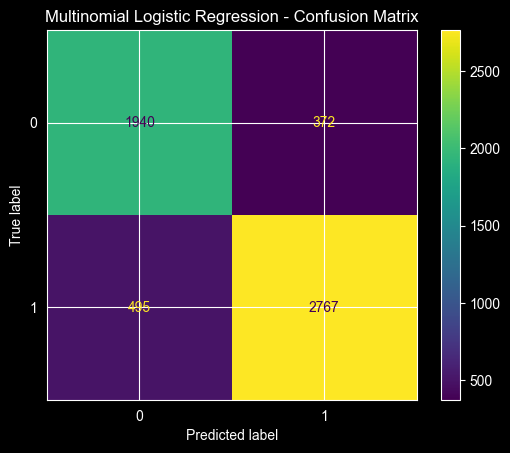

In [12]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()

In [13]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2312
           1       0.87      0.84      0.85      3262

    accuracy                           0.83      5574
   macro avg       0.82      0.83      0.82      5574
weighted avg       0.83      0.83      0.83      5574

Decision Tree Macro F1: 0.8232481004337759
Decision Tree Weighted F1: 0.827771648656478


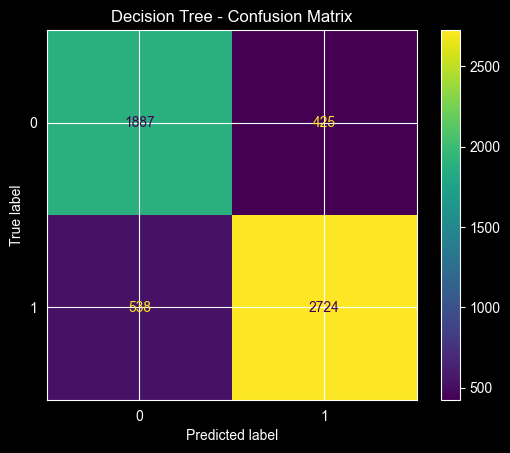

In [14]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_tree))

macro_f1_tree = f1_score(y_test, y_pred_tree, average="macro")
weighted_f1_tree = f1_score(y_test, y_pred_tree, average="weighted")

print("Decision Tree Macro F1:", macro_f1_tree)
print("Decision Tree Weighted F1:", weighted_f1_tree)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Have you ever had suicidal thoughts ?_yes    0.558853
Academic Pressure                            0.252444
Financial Stress                             0.108527
Age                                          0.040008
Work/Study Hours                             0.015267
Dietary Habits_Unhealthy                     0.012044
Dietary Habits_Healthy                       0.006460
Study Satisfaction                           0.005635
Sleep Duration_5-6 hours                     0.000761
CGPA__missing                                0.000000
CGPA                                         0.000000
Sleep Duration_Less than 5 hours             0.000000
Sleep Duration_More than 8 hours             0.000000
Gender_female                                0.000000
Financial Stress__missing                    0.000000
dtype: float64


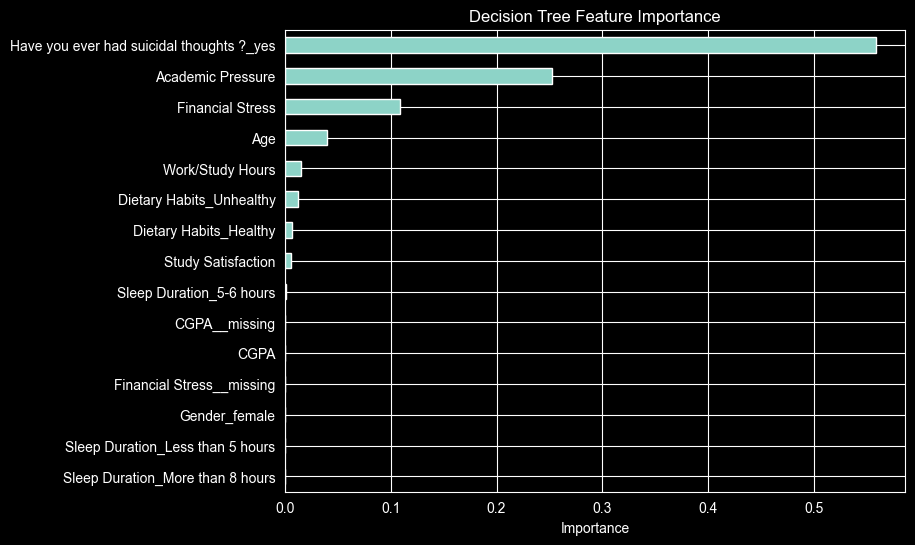

In [15]:
import pandas as pd

tree_importance = pd.Series(
    tree.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(tree_importance.head(15))
tree_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.show()

                                      feature  importance_mean  importance_std
21  Have you ever had suicidal thoughts ?_yes         0.114339        0.003090
1                           Academic Pressure         0.100887        0.004513
5                            Financial Stress         0.039325        0.003299
0                                         Age         0.015252        0.001857
15                   Dietary Habits_Unhealthy         0.008896        0.001526
13                     Dietary Habits_Healthy         0.001218        0.001243
4                            Work/Study Hours         0.000701        0.000992
3                          Study Satisfaction         0.000674        0.000802
9                    Sleep Duration_5-6 hours         0.000427        0.000257
6                               CGPA__missing         0.000000        0.000000
2                                        CGPA         0.000000        0.000000
10           Sleep Duration_Less than 5 hours       

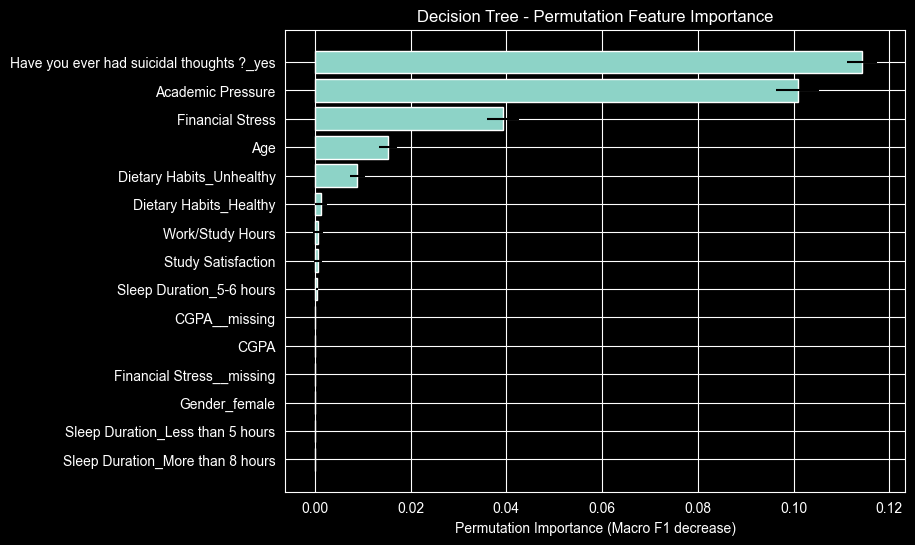

In [24]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

perm_tree = permutation_importance(
    tree,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_tree_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_tree.importances_mean,
    "importance_std": perm_tree.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_tree_df.head(15))

top_features_tree = perm_tree_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features_tree["feature"],
    top_features_tree["importance_mean"],
    xerr=top_features_tree["importance_std"]
)
plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Decision Tree - Permutation Feature Importance")
plt.show()

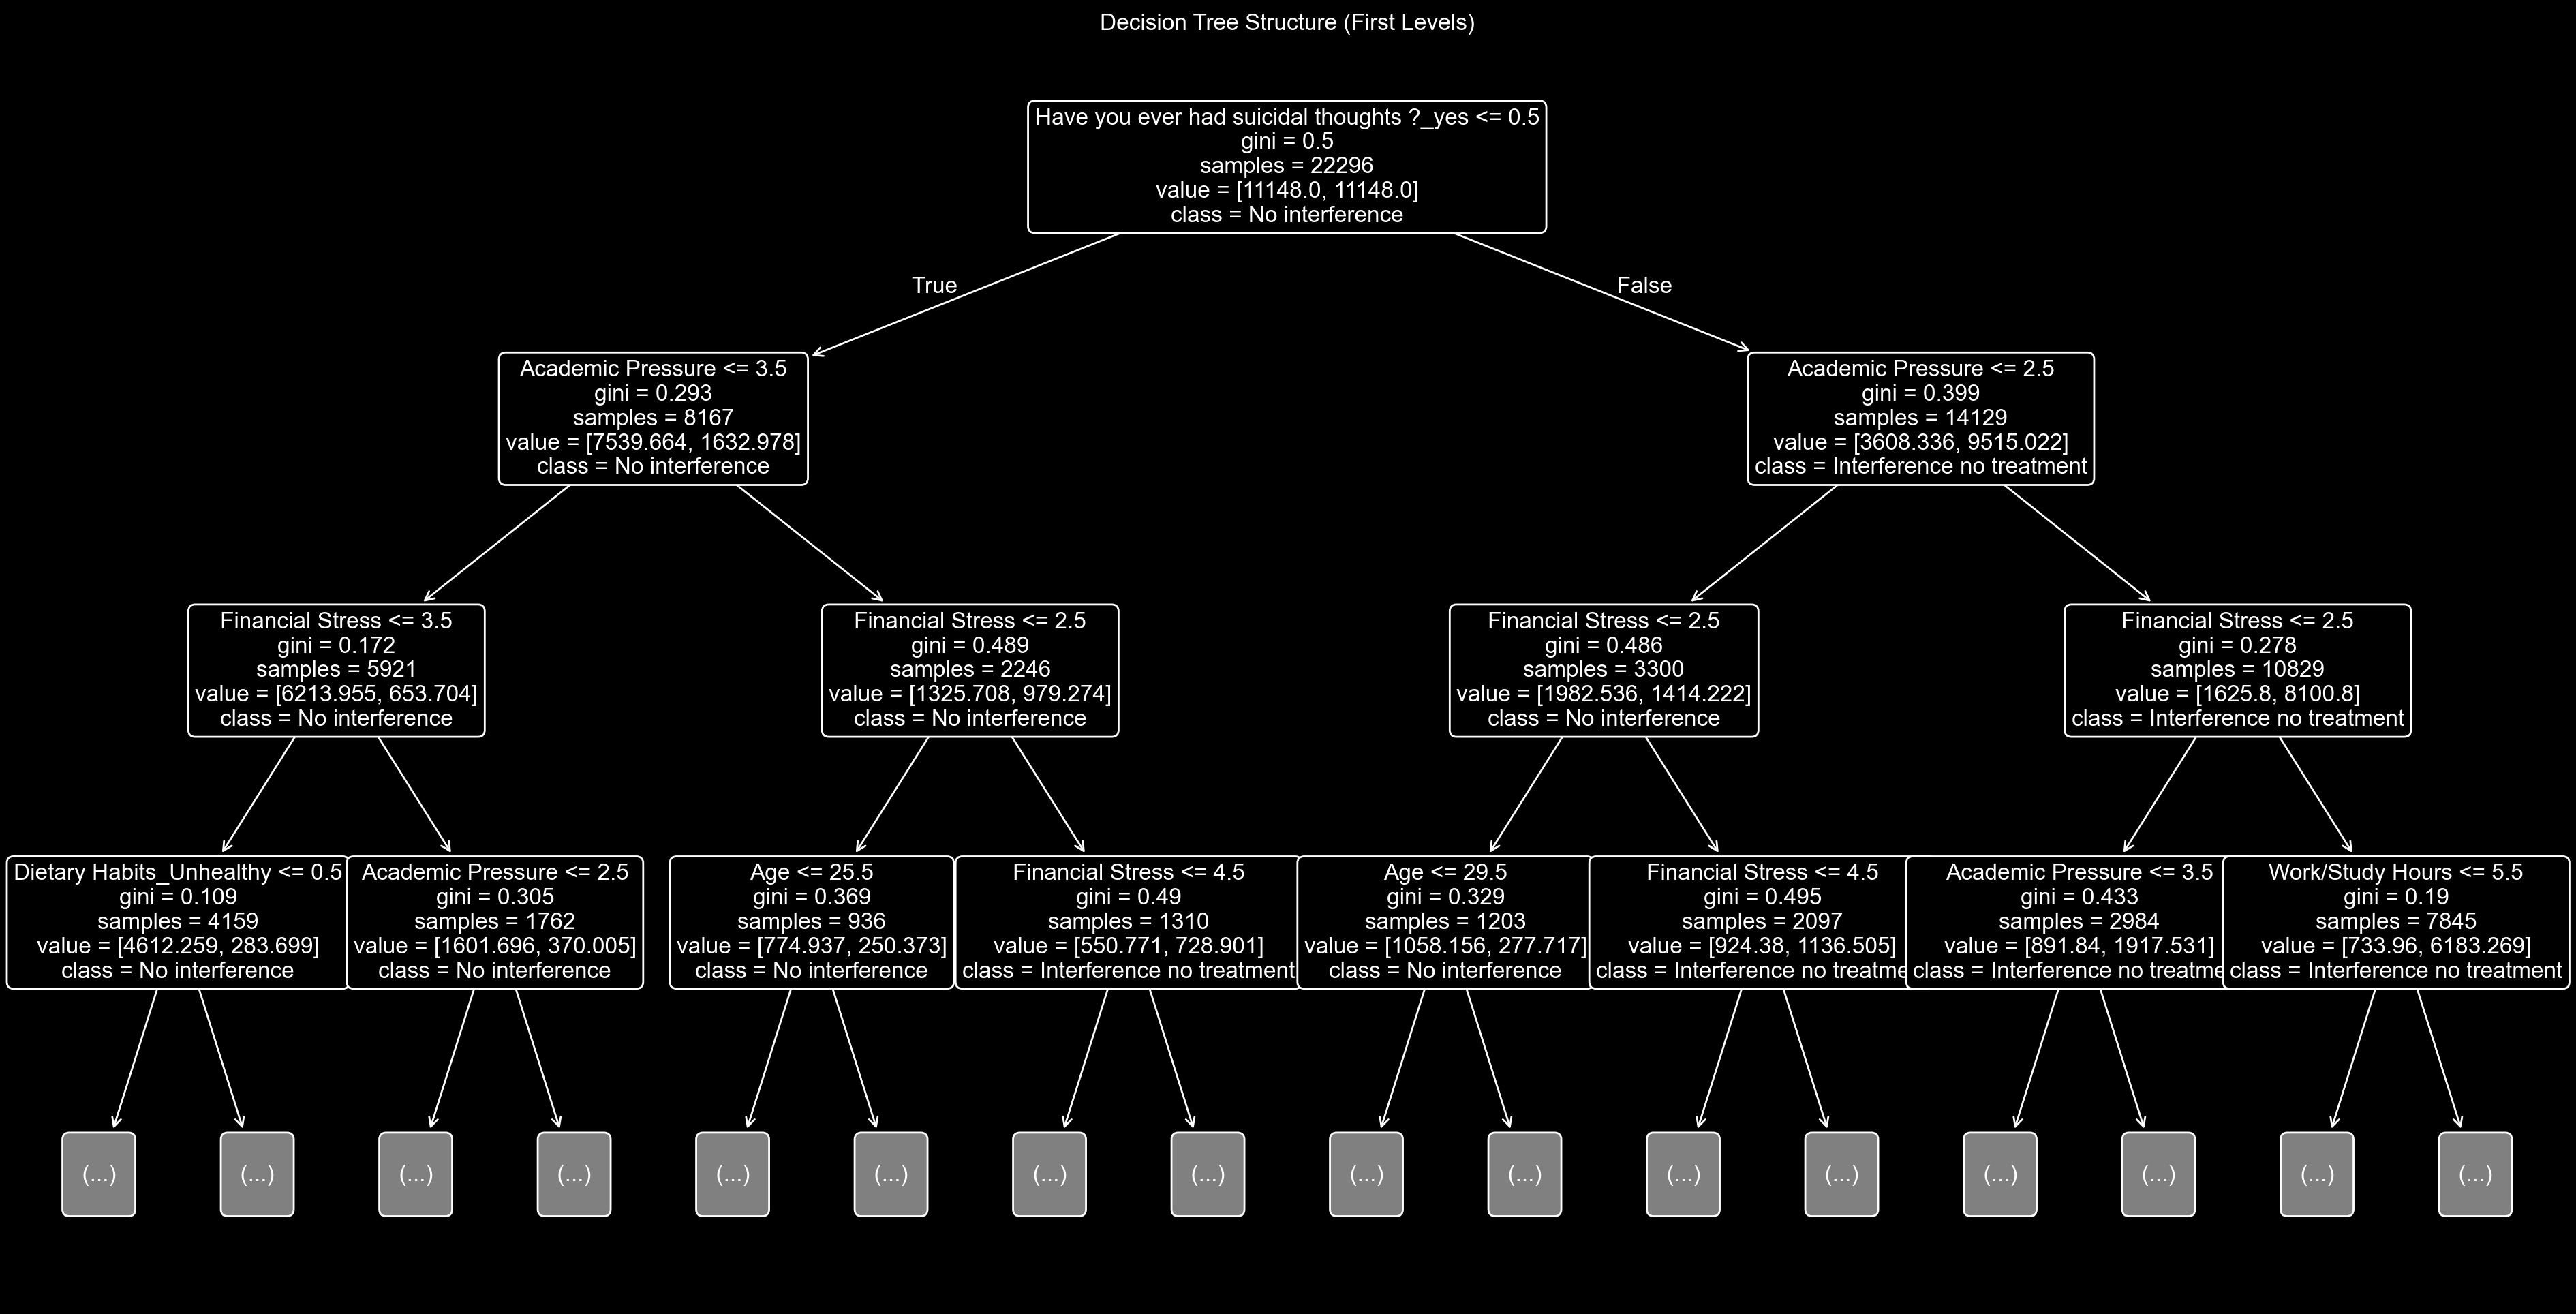

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24,12), dpi=200)

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No interference","Interference no treatment","Interference + treatment"],
    rounded=True,
    max_depth=3,
    fontsize=12
)

plt.title("Decision Tree Structure (First Levels)")
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      2312
           1       0.86      0.87      0.86      3262

    accuracy                           0.84      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.84      0.84      0.84      5574

Random Forest Macro F1: 0.836990307486631
Random Forest Weighted F1: 0.8417453179774699


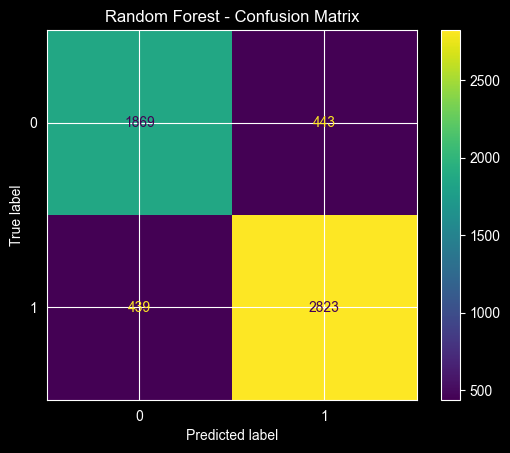

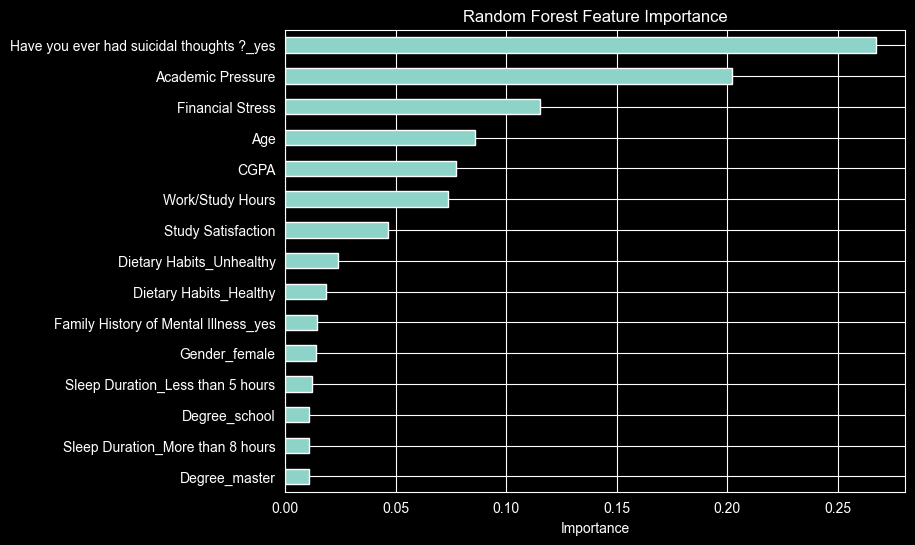

In [18]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

print(classification_report(y_test, y_pred_rf))

macro_f1_rf = f1_score(y_test, y_pred_rf, average="macro")
weighted_f1_rf = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Macro F1:", macro_f1_rf)
print("Random Forest Weighted F1:", weighted_f1_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest - Confusion Matrix")
plt.show()

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15)
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

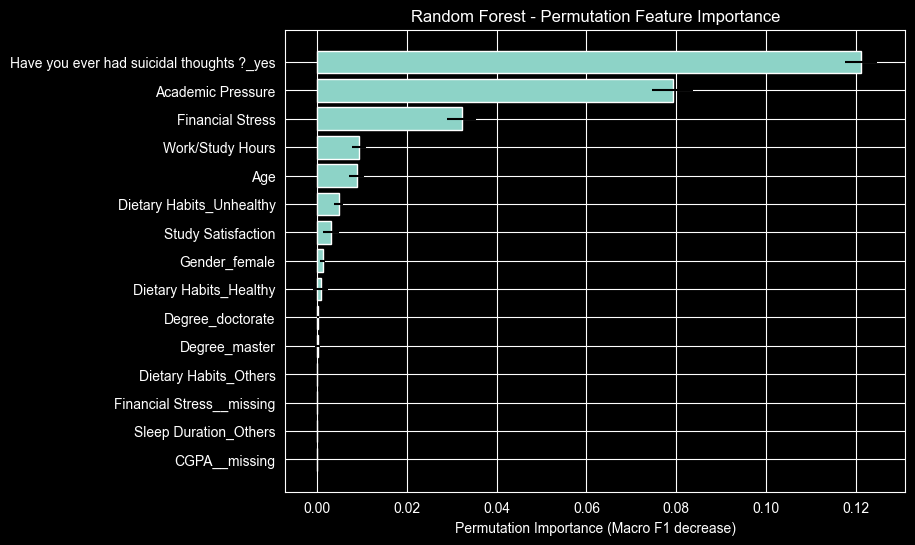

In [19]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

perm_importance_df.head(15)

top_features = perm_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("Random Forest - Permutation Feature Importance")
plt.show()

In [20]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      2312
           1       0.86      0.89      0.87      3262

    accuracy                           0.85      5574
   macro avg       0.84      0.84      0.84      5574
weighted avg       0.85      0.85      0.85      5574

XGBoost Macro F1: 0.8418959590717462
XGBoost Weighted F1: 0.8469719629549767


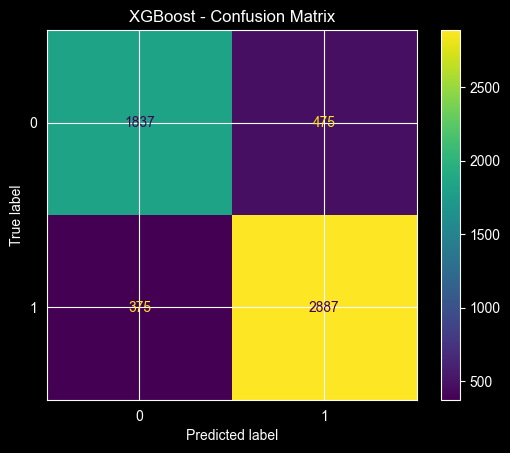

In [21]:
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred_xgb))

macro_f1_xgb = f1_score(y_test, y_pred_xgb, average="macro")
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average="weighted")

print("XGBoost Macro F1:", macro_f1_xgb)
print("XGBoost Weighted F1:", weighted_f1_xgb)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("XGBoost - Confusion Matrix")
plt.show()

Have you ever had suicidal thoughts ?_yes    0.520879
Academic Pressure                            0.161261
Financial Stress                             0.077132
Dietary Habits_Unhealthy                     0.034845
Dietary Habits_Healthy                       0.031320
Age                                          0.024717
Work/Study Hours                             0.023873
Study Satisfaction                           0.022145
Sleep Duration_More than 8 hours             0.015973
Sleep Duration_Less than 5 hours             0.015905
Family History of Mental Illness_yes         0.011318
Degree_school                                0.011165
CGPA                                         0.007331
Gender_female                                0.006916
Degree_professional                          0.006863
dtype: float32


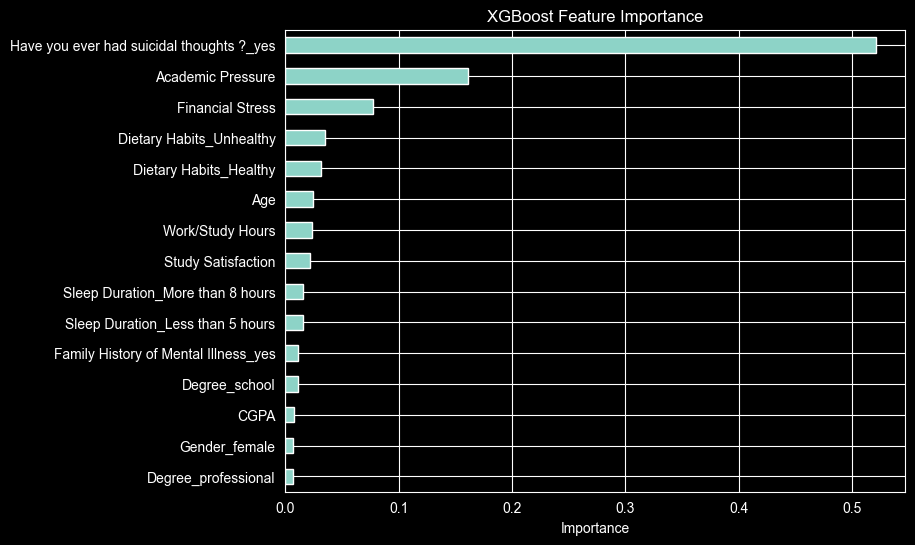

In [22]:
import pandas as pd

xgb_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(xgb_importance.head(15))

xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6)
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

                                      feature  importance_mean  importance_std
21  Have you ever had suicidal thoughts ?_yes         0.108649        0.002568
1                           Academic Pressure         0.084071        0.003476
5                            Financial Stress         0.035598        0.002733
0                                         Age         0.015374        0.002699
4                            Work/Study Hours         0.013505        0.001819
15                   Dietary Habits_Unhealthy         0.005772        0.001476
3                          Study Satisfaction         0.005419        0.001272
13                     Dietary Habits_Healthy         0.002302        0.001248
10           Sleep Duration_Less than 5 hours         0.001648        0.001115
11           Sleep Duration_More than 8 hours         0.001292        0.001015
20                              Degree_school         0.000822        0.000711
17                              Degree_master       

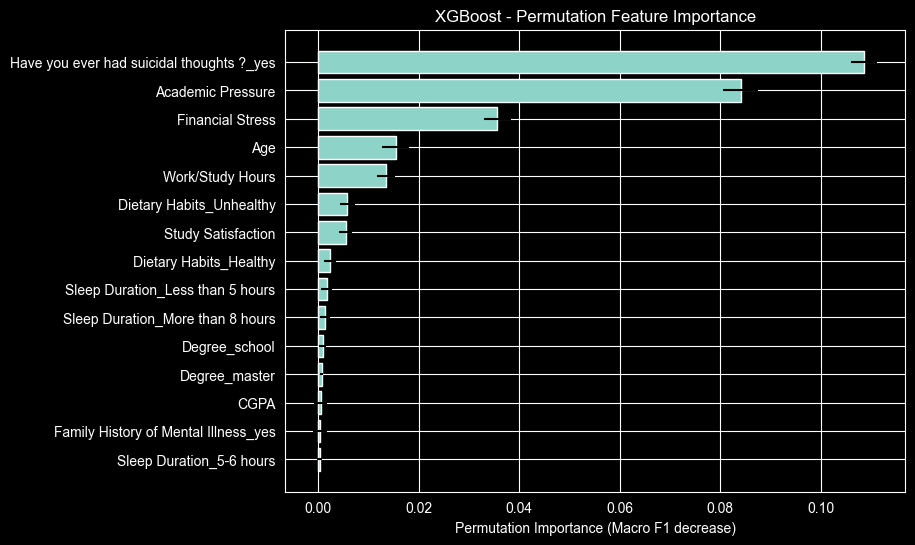

In [23]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_macro",
    n_jobs=4
)

perm_xgb_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_xgb.importances_mean,
    "importance_std": perm_xgb.importances_std
}).sort_values("importance_mean", ascending=False)

print(perm_xgb_df.head(15))

top_features = perm_xgb_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"]
)

plt.xlabel("Permutation Importance (Macro F1 decrease)")
plt.title("XGBoost - Permutation Feature Importance")
plt.show()

In [25]:
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "f1_macro":    make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted"),
}

models = {
    "Logistic Regression": logreg,
    "Decision Tree":       tree,
    "Random Forest":       rf,
    "XGBoost":             xgb,
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    # AUC — binary so no multiclass handling needed
    y_prob_cv = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]  # probability of positive class

    auc = roc_auc_score(y, y_prob_cv)

    cv_results[name] = {
        "F1 Macro (mean)":    round(scores["test_f1_macro"].mean(), 3),
        "F1 Macro (std)":     round(scores["test_f1_macro"].std(),  3),
        "F1 Weighted (mean)": round(scores["test_f1_weighted"].mean(), 3),
        "F1 Weighted (std)":  round(scores["test_f1_weighted"].std(),  3),
        "AUC":                round(auc, 3),
    }

cv_df = pd.DataFrame(cv_results).T
print(cv_df)

                     F1 Macro (mean)  F1 Macro (std)  F1 Weighted (mean)  \
Logistic Regression            0.841           0.005               0.845   
Decision Tree                  0.822           0.006               0.827   
Random Forest                  0.837           0.005               0.842   
XGBoost                        0.841           0.004               0.847   

                     F1 Weighted (std)    AUC  
Logistic Regression              0.005  0.921  
Decision Tree                    0.006  0.901  
Random Forest                    0.005  0.917  
XGBoost                          0.003  0.921  


In [26]:
results = pd.DataFrame([
    {
        "Model":              "Logistic Regression",
        "Macro F1 (test)":    round(macro_f1, 3),
        "Weighted F1 (test)": round(weighted_f1, 3),
        "CV Macro F1":        cv_df.loc["Logistic Regression", "F1 Macro (mean)"],
        "CV Macro F1 std":    cv_df.loc["Logistic Regression", "F1 Macro (std)"],
        "AUC":                cv_df.loc["Logistic Regression", "AUC"],
    },
    {
        "Model":              "Decision Tree",
        "Macro F1 (test)":    round(macro_f1_tree, 3),
        "Weighted F1 (test)": round(weighted_f1_tree, 3),
        "CV Macro F1":        cv_df.loc["Decision Tree", "F1 Macro (mean)"],
        "CV Macro F1 std":    cv_df.loc["Decision Tree", "F1 Macro (std)"],
        "AUC":                cv_df.loc["Decision Tree", "AUC"],
    },
    {
        "Model":              "Random Forest",
        "Macro F1 (test)":    round(macro_f1_rf, 3),
        "Weighted F1 (test)": round(weighted_f1_rf, 3),
        "CV Macro F1":        cv_df.loc["Random Forest", "F1 Macro (mean)"],
        "CV Macro F1 std":    cv_df.loc["Random Forest", "F1 Macro (std)"],
        "AUC":                cv_df.loc["Random Forest", "AUC"],
    },
    {
        "Model":              "XGBoost",
        "Macro F1 (test)":    round(macro_f1_xgb, 3),
        "Weighted F1 (test)": round(weighted_f1_xgb, 3),
        "CV Macro F1":        cv_df.loc["XGBoost", "F1 Macro (mean)"],
        "CV Macro F1 std":    cv_df.loc["XGBoost", "F1 Macro (std)"],
        "AUC":                cv_df.loc["XGBoost", "AUC"],
    },
]).set_index("Model")

print(results)

                     Macro F1 (test)  Weighted F1 (test)  CV Macro F1  \
Model                                                                   
Logistic Regression            0.841               0.845        0.841   
Decision Tree                  0.823               0.828        0.822   
Random Forest                  0.837               0.842        0.837   
XGBoost                        0.842               0.847        0.841   

                     CV Macro F1 std    AUC  
Model                                        
Logistic Regression            0.005  0.921  
Decision Tree                  0.006  0.901  
Random Forest                  0.005  0.917  
XGBoost                        0.004  0.921  


In [ ]:
## Baseline Models — Results Summary (Student Depression Dataset)

### Dataset
# - 27,870 student rows after filtering non-student professions (0.1% dropped)
# - Binary target: Depression (1 = depressed, 0 = not depressed)
# - Dropped columns: City (data quality), Profession (post-filter),
#   Work Pressure (not applicable), Job Satisfaction (not applicable)
# - Class distribution: moderately imbalanced toward depressed class,
#   addressed via class_weight="balanced"

### Model Configuration
# Hyperparameters set using principled defaults, consistent across all
# datasets. No dataset-specific tuning performed.

### Key Findings
# - All models perform substantially better than MH Tech
#   (CV Macro F1 ~0.82–0.84 vs ~0.41–0.47), suggesting student
#   depression features are more directly predictive of the outcome.
# - XGBoost and Logistic Regression tie for best performance
#   (CV Macro F1: 0.841, AUC: 0.921), indicating the outcome is
#   largely linearly separable after feature engineering.
# - Random Forest is marginally behind (CV Macro F1: 0.837, AUC: 0.917),
#   unusual relative to MH Tech where RF led — suggesting boosting
#   and linear models are better suited to this data structure.
# - Decision Tree is the weakest model (CV Macro F1: 0.822, AUC: 0.901),
#   consistent with MH Tech findings.
# - CV std is very low across all models (0.003–0.006), indicating
#   highly stable generalization — a consequence of the large sample
#   size (n=27,870).
# - Test set Macro F1 and CV Macro F1 are nearly identical across all
#   models, confirming no meaningful overfitting to the test split.

### Important Caveat — Suicidal Ideation Feature
# "Have you ever had suicidal thoughts?" accounts for ~52–56% of
# intrinsic importance across tree models and ~0.108 permutation
# importance in XGBoost — far above all other features. This feature
# overlaps conceptually with depression as a construct, raising
# questions about whether it is a predictor or a co-symptom. A
# sensitivity analysis with this feature removed is planned.

### Comparison with MH Tech Dataset
# Higher performance on this dataset is consistent with RQ1 —
# individual-level data with well-defined psychological indicators
# yields more accurate predictions than workplace survey data with
# broader, noisier features. The near-zero gap between test and CV
# scores also reflects the benefit of a large sample size for
# stable model evaluation.